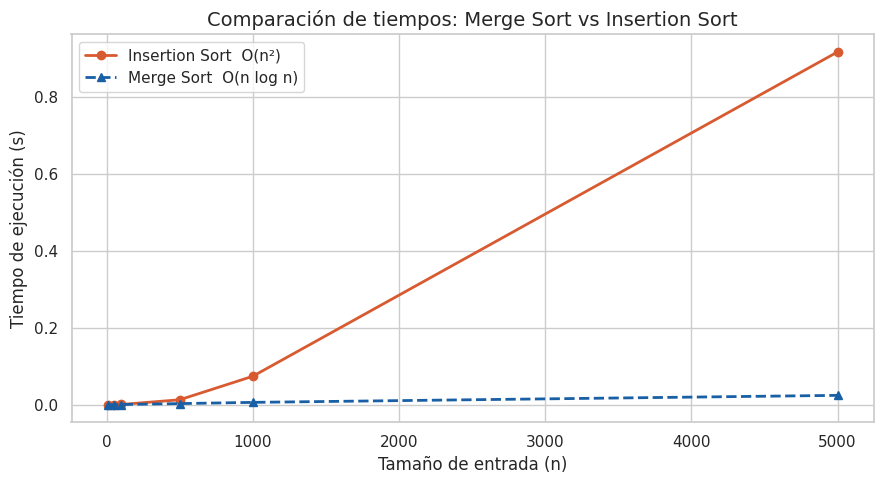


     n    Insertion Sort (s)    Merge Sort (s)
------------------------------------------------
    10              0.000007          0.000023  
    50              0.000097          0.000138  
   100              0.000399          0.000271  <-- más rápido
   500              0.012581          0.002646  <-- más rápido
  1000              0.073771          0.005860  <-- más rápido
  5000              0.918450          0.024126  <-- más rápido


In [1]:
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns


# ─────────────────────────────────────────────
# 1. Insertion Sort  O(n²)
# ─────────────────────────────────────────────
def insertion_sort(arreglo):
    arr = arreglo[:]          # copia para no modificar el original
    for i in range(1, len(arr)):
        clave = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > clave:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = clave
    return arr


# ─────────────────────────────────────────────
# 2. Merge Sort  O(n log n)
# ─────────────────────────────────────────────
def merge(izquierda, derecha):
    resultado = []
    i = j = 0
    while i < len(izquierda) and j < len(derecha):
        if izquierda[i] < derecha[j]:
            resultado.append(izquierda[i])
            i += 1
        else:
            resultado.append(derecha[j])
            j += 1
    resultado.extend(izquierda[i:])
    resultado.extend(derecha[j:])
    return resultado


def merge_sort(arreglo):
    if len(arreglo) <= 1:
        return arreglo
    medio = len(arreglo) // 2
    izquierda = merge_sort(arreglo[:medio])
    derecha   = merge_sort(arreglo[medio:])
    return merge(izquierda, derecha)


# ─────────────────────────────────────────────
# 3. Medición de tiempos
# ─────────────────────────────────────────────
sizes = [10, 50, 100, 500, 1000, 5000]
REPETITIONS = 5

insertion_times = []
merge_times     = []

for n in sizes:
    arr = [random.randint(-1000, 1000) for _ in range(n)]

    # Insertion Sort
    t0 = time.perf_counter()
    for _ in range(REPETITIONS):
        insertion_sort(arr)
    insertion_times.append((time.perf_counter() - t0) / REPETITIONS)

    # Merge Sort
    t0 = time.perf_counter()
    for _ in range(REPETITIONS):
        merge_sort(arr)
    merge_times.append((time.perf_counter() - t0) / REPETITIONS)


# ─────────────────────────────────────────────
# 4. Gráfica comparativa
# ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sizes, insertion_times, marker="o",  linewidth=2,
        label="Insertion Sort  O(n²)",      color="#d85a30")
ax.plot(sizes, merge_times,     marker="^",  linewidth=2, linestyle="--",
        label="Merge Sort  O(n log n)",     color="#185fa5")

ax.set_xlabel("Tamaño de entrada (n)", fontsize=12)
ax.set_ylabel("Tiempo de ejecución (s)", fontsize=12)
ax.set_title("Comparación de tiempos: Merge Sort vs Insertion Sort", fontsize=14)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))

plt.tight_layout()
plt.savefig("merge_vs_insertion.png", dpi=150)
plt.show()


# ─────────────────────────────────────────────
# 5. Tabla de resultados en consola
# ─────────────────────────────────────────────
print(f"\n{'n':>6}  {'Insertion Sort (s)':>20}  {'Merge Sort (s)':>16}")
print("-" * 48)
for n, it, mt in zip(sizes, insertion_times, merge_times):
    ganador = "<-- más rápido" if mt < it else ""
    print(f"{n:>6}  {it:>20.6f}  {mt:>16.6f}  {ganador}")